# 03 — Primeiro gráfico: a série de `PercentualdeDevolucao`

**Objetivo:** plotar o percentual de devolução mês a mês e escrever o que o
gráfico mostra — e o que ele não mostra.

Faz parte da [etapa 4](../PLANO.md) do projeto. A base já foi validada nas
etapas 2 e 3: completa (52 meses, sem lacuna) e com a fórmula confirmada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados/fraude.csv"
df = pd.read_csv(URL)
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)
df[["Data", "PercentualdeDevolucao"]].head()

,Data,PercentualdeDevolucao
0,2022-01-01,5.29
1,2022-02-01,5.99
2,2022-03-01,7.84
3,2022-04-01,6.78
4,2022-05-01,5.49


## Primeiro gráfico, sem ajuste nenhum

<Axes: xlabel='Data'>

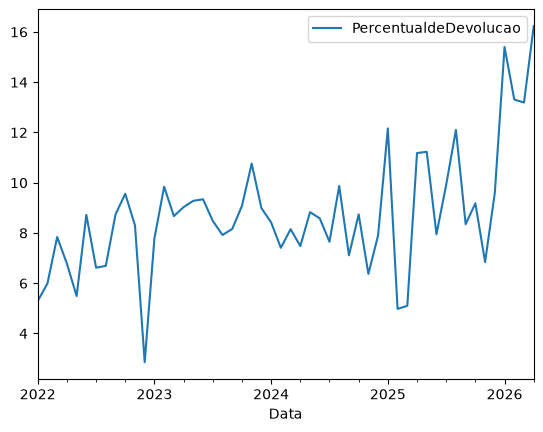

In [2]:
df.plot(x="Data", y="PercentualdeDevolucao")

Funciona, mas não diz nada sozinho: eixo Y começa perto de 3 em vez de zero
(exagera a variação visualmente), não tem título, a legenda ("PercentualdeDevolucao")
é o nome da coluna, não uma frase, e as bordas de cima e da direita não
ajudam em nada.

## Com eixo e título ajustados

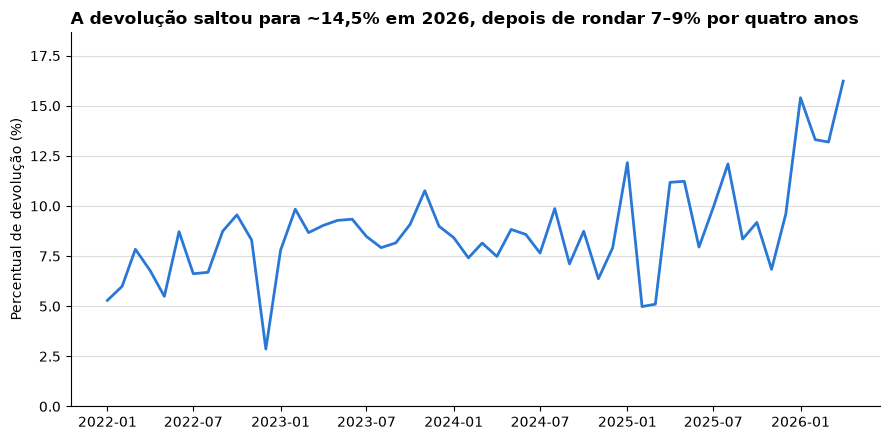

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(df["Data"], df["PercentualdeDevolucao"], color="#2a78d6", linewidth=2)

ax.set_ylim(0, df["PercentualdeDevolucao"].max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    "A devolução saltou para ~14,5% em 2026, depois de rondar 7–9% por quatro anos",
    loc="left", fontsize=12, fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Percentual de devolução (%)")

plt.tight_layout()
plt.savefig("../graficos/03-percentual-devolucao.png", dpi=150)
plt.show()

## O que o gráfico mostra — e o que não mostra

**Mostra:**

- O percentual de devolução ficou entre 2,9% e 9,9% em praticamente toda a
  série (2022 a 2025), com média anual subindo devagar ano a ano (6,9% → 8,9%
  → 8,0% → 9,0%).
- Os quatro primeiros meses de 2026 destoam claramente do resto: 13,2% a
  16,2%, bem acima do teto dos quatro anos anteriores.

**Não mostra** (e seria erro ler como se mostrasse):

- **Por que** a devolução subiu em 2026. O gráfico descreve uma mudança, não
  explica — essa é a etapa 6 (contexto regulatório), que ainda não foi feita.
- Se o patamar de 2026 **vai se manter**. São só 4 meses contra 48 dos anos
  anteriores — amostra pequena demais pra chamar de tendência consolidada.
- O **volume** por trás do percentual. Um percentual mais alto sobre uma base
  de contestações maior (a etapa 5 mostra que elas cresceram muito a partir
  de out/2025) não é a mesma coisa que um percentual mais alto sobre uma base
  estável. Isso ainda não foi separado aqui.